In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from diptest import diptest

In [2]:
def get_rare(ctp_path, per):
    dt = pd.read_csv(ctp_path)
    celltypes = dt.columns[1:].values
    print (celltypes, len(celltypes), "\n")
    dt = dt[celltypes]
    dt = dt.mean()
    rare = dt.sort_values()[: round(per*len(dt))]
    return rare
    
def bi_modal(data):
    # Sample data
    #data = np.random.normal(0, 1, 500).tolist() + np.random.normal(5, 1, 500).tolist()
    
    # Convert list to NumPy array
    data = np.array(data)
    # Statistical Test: Dip Test
    dip_stat, p_value = diptest(data)
    print(f"Dip Statistic: {dip_stat}, p-value: {p_value}")
    
    # Interpretation
    if p_value < 0.05:
        print("The data is likely bimodal (reject the null hypothesis of unimodality).")
        return True
    else:
        print("The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).")
        return False


In [3]:
def binned_data(ctp_path, bottom_50):

    df = pd.read_csv(ctp_path)
    
    bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    dt = pd.DataFrame({        
    'Range': ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']    
    })

    plt.figure(figsize=(12, 8))

    new_cols = [df.columns[0]] + bottom_50.tolist() 
    print (new_cols)
    
    df = df[new_cols]
    
    for column in df.columns[1:]:
        sns.kdeplot(df[column], label=column, bw_adjust=0.5)
    
    plt.title('KDE Plots')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend(title='Columns')
    plt.show()

    cell_type = []

    
    for c in df.columns[1:]:
        print (c, "\n")
        flag = bi_modal(df[c])
        if (flag):
            cell_type += [c]
            
        
    binned_ct = {}
    for c in df.columns[1:]:   
        
        binned_ct[c] = pd.cut(df[c], bins = bins)
        dt[c + "_count"] = binned_ct[c].value_counts(sort = False).values

    print (cell_type)
    cell_type = [element + "_count" for element in cell_type]
    dt = dt.T
    

    return (dt[dt.index.isin(cell_type)], dt)

### Brain

['AST_FB' 'AST_PP' 'Endothelial' 'IN_PV' 'IN_SST' 'IN_SV2C' 'IN_VIP'
 'L2_3' 'L4' 'L5_6' 'L5_6_CC' 'Microglia' 'Neu_NRGN_I' 'Neu_NRGN_II'
 'Neu_mat' 'OPC' 'Oligodendrocytes'] 17 

['Microglia' 'IN_SV2C' 'OPC' 'IN_SST' 'IN_VIP']
['Unnamed: 0', 'Microglia', 'IN_SV2C', 'OPC', 'IN_SST', 'IN_VIP']


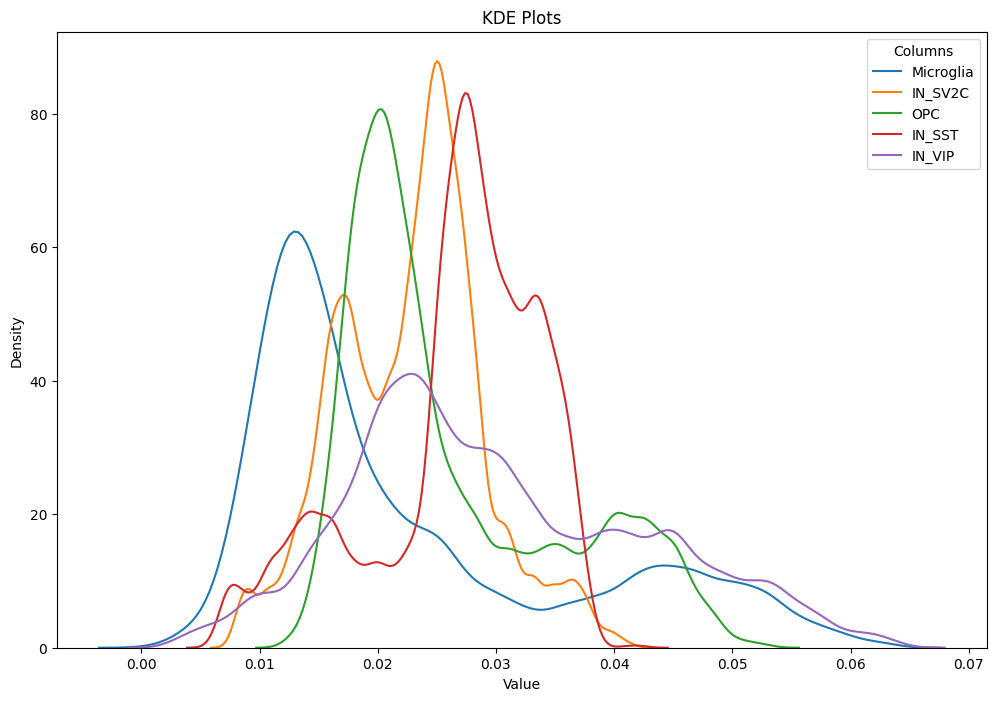

Microglia 

Dip Statistic: 0.013328239363792264, p-value: 0.00016797879773156055
The data is likely bimodal (reject the null hypothesis of unimodality).
IN_SV2C 

Dip Statistic: 0.011227041822715113, p-value: 0.003671167161995781
The data is likely bimodal (reject the null hypothesis of unimodality).
OPC 

Dip Statistic: 0.009340970600382444, p-value: 0.03598808957804078
The data is likely bimodal (reject the null hypothesis of unimodality).
IN_SST 

Dip Statistic: 0.009558639931417262, p-value: 0.02822281315226527
The data is likely bimodal (reject the null hypothesis of unimodality).
IN_VIP 

Dip Statistic: 0.004067916533854797, p-value: 0.9879207175152585
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
['Microglia', 'IN_SV2C', 'OPC', 'IN_SST']
                    0  1  2  3  4  5  6  7  8
Microglia_count  3639  0  0  0  0  0  0  0  0
IN_SV2C_count    3639  0  0  0  0  0  0  0  0
OPC_count        3639  0  0  0  0  0  0  0  0
IN_SST_count    

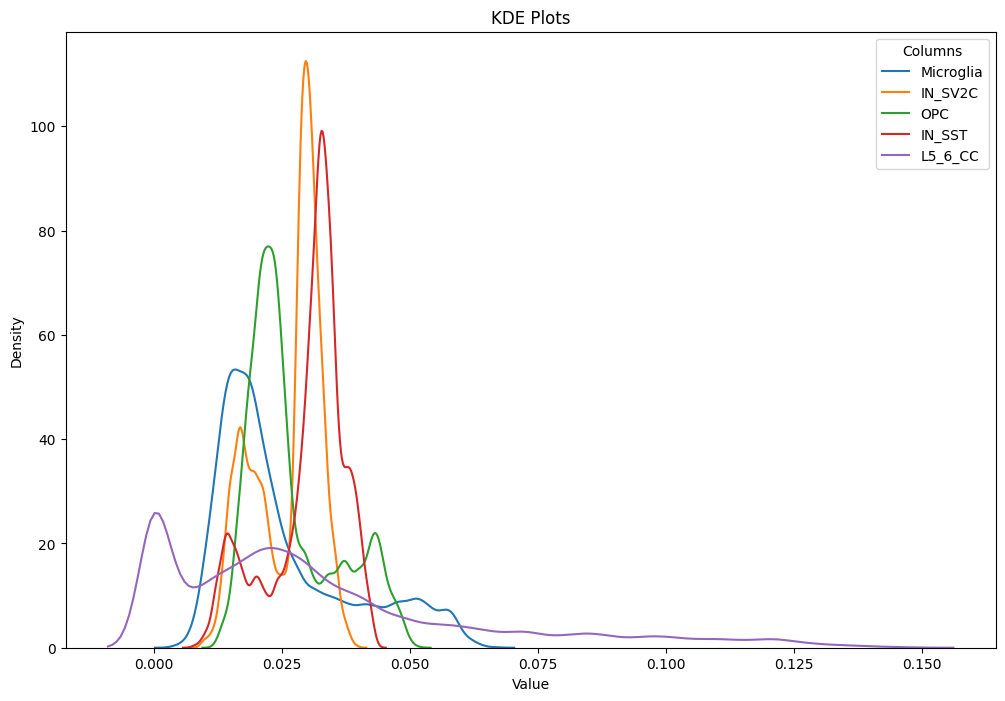

Microglia 

Dip Statistic: 0.0032119758226602656, p-value: 0.9970213470073311
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
IN_SV2C 

Dip Statistic: 0.029497935843867798, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
OPC 

Dip Statistic: 0.009440980486677387, p-value: 0.0308681977681875
The data is likely bimodal (reject the null hypothesis of unimodality).
IN_SST 

Dip Statistic: 0.011553610585900615, p-value: 0.002013974072588298
The data is likely bimodal (reject the null hypothesis of unimodality).
L5_6_CC 

Dip Statistic: 0.028253372179851906, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
['IN_SV2C', 'OPC', 'IN_SST', 'L5_6_CC']
                  0    1  2  3  4  5  6  7  8
IN_SV2C_count  3673    0  0  0  0  0  0  0  0
OPC_count      3673    0  0  0  0  0  0  0  0
IN_SST_count   3673    0  0  0  0  0  0  0  0
L5_6_CC_count  2908  194  0  0  0  0  0  0  0


In [10]:
lst = {
        "Brain" : ["151508", "151509", "151669", "151670", "151673", "151674"],
      "Cancer": [],
      "Development" : []
    }


lst["Brain"] =  ["151673", "151674"]

for l in lst["Brain"]:
    #data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/" + l + "/ST.h5ad"
    data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/DLPFC/simulator_outputs/simulated_gene_expression" + l + "_average.h5ad"
    ctp_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/DLPFC/simulator_outputs/Ground_Truth_CTP_" + l + ".csv"
    
    rare = get_rare(ctp_path, 0.3)
    
    bottom_50 = rare.index.values
    
    print (bottom_50)
    
    
    dt, dt_unfil = binned_data(ctp_path, bottom_50)
    
    print (dt)

['Astro_AMY' 'Astro_AMY_CTX' 'Astro_CTX' 'Astro_HPC' 'Astro_HYPO'
 'Astro_STR' 'Astro_THAL_hab' 'Astro_THAL_lat' 'Astro_THAL_med' 'Astro_WM'
 'Endo' 'Ext_Amy_1' 'Ext_Amy_2' 'Ext_ClauPyr' 'Ext_Hpc_CA1' 'Ext_Hpc_CA2'
 'Ext_Hpc_CA3' 'Ext_Hpc_DG1' 'Ext_Hpc_DG2' 'Ext_L23' 'Ext_L25' 'Ext_L56'
 'Ext_L5_1' 'Ext_L5_2' 'Ext_L5_3' 'Ext_L6' 'Ext_L6B' 'Ext_Med' 'Ext_Pir'
 'Ext_Thal_1' 'Ext_Thal_2' 'Ext_Unk_1' 'Ext_Unk_2' 'Ext_Unk_3' 'Inh_1'
 'Inh_2' 'Inh_3' 'Inh_4' 'Inh_5' 'Inh_6' 'Inh_Lamp5' 'Inh_Meis2_1'
 'Inh_Meis2_2' 'Inh_Meis2_3' 'Inh_Meis2_4' 'Inh_Pvalb' 'Inh_Sst' 'Inh_Vip'
 'LowQ_1' 'LowQ_2' 'Micro' 'Nb_1' 'Nb_2' 'OPC_1' 'OPC_2' 'Oligo_1'
 'Oligo_2' 'Unk_1' 'Unk_2'] 59 

['Ext_Unk_1' 'Unk_2' 'Nb_1' 'Astro_CTX' 'Inh_1' 'Inh_Meis2_1'
 'Astro_THAL_med' 'Ext_L5_3' 'LowQ_2' 'Ext_Hpc_CA2' 'Ext_L6' 'Inh_2']
['Unnamed: 0', 'Ext_Unk_1', 'Unk_2', 'Nb_1', 'Astro_CTX', 'Inh_1', 'Inh_Meis2_1', 'Astro_THAL_med', 'Ext_L5_3', 'LowQ_2', 'Ext_Hpc_CA2', 'Ext_L6', 'Inh_2']


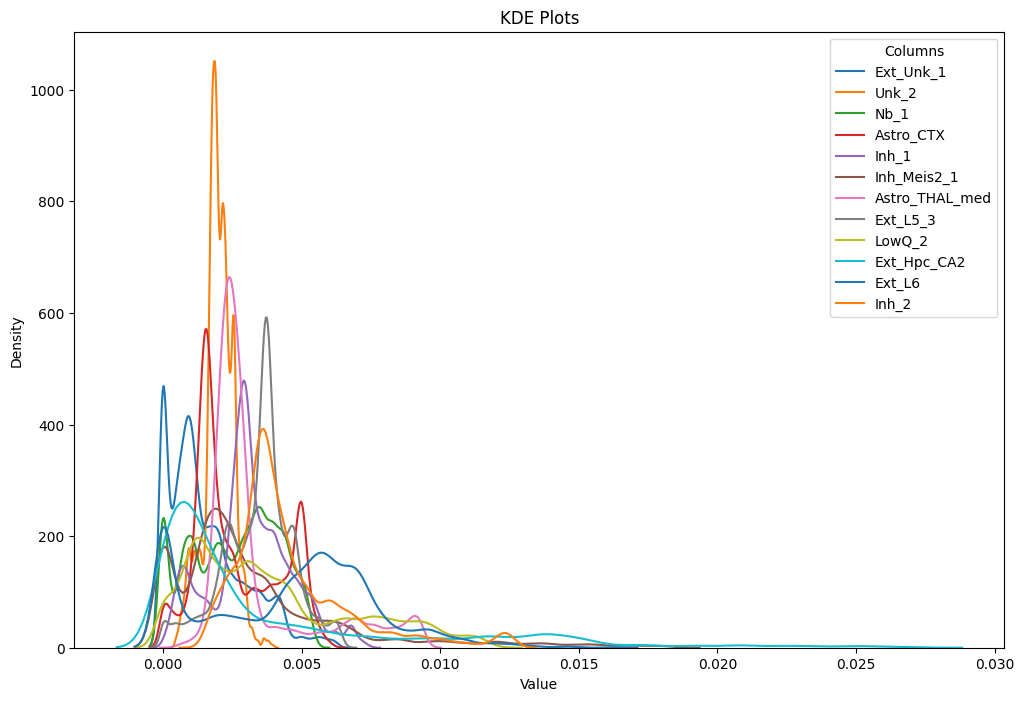

Ext_Unk_1 

Dip Statistic: 0.0304412799556418, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
Unk_2 

Dip Statistic: 0.008443812817189597, p-value: 0.3483671782394566
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
Nb_1 

Dip Statistic: 0.039304123711340205, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
Astro_CTX 

Dip Statistic: 0.03079289074445934, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
Inh_1 

Dip Statistic: 0.01352174252009796, p-value: 0.005752271875064219
The data is likely bimodal (reject the null hypothesis of unimodality).
Inh_Meis2_1 

Dip Statistic: 0.0558775428903004, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
Astro_THAL_med 

Dip Statistic: 0.01257697807946143, p-value: 0.01507029543617544
The data is likely bimodal (reject the null hypothesis of unimodality).
Ext_L5_3

In [11]:
data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Mouse_Brain/simulator_outputs/ST48/simulated_gene_expression_average.h5ad"
ctp_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Mouse_Brain/simulator_outputs/ST48/Ground_Truth_CTP.csv"

rare = get_rare(ctp_path, 0.2)

bottom_50 = rare.index.values

print (bottom_50)


dt, dt_unfil = binned_data(ctp_path, bottom_50)

print (dt)


['Astro_AMY' 'Astro_AMY_CTX' 'Astro_CTX' 'Astro_HPC' 'Astro_HYPO'
 'Astro_STR' 'Astro_THAL_hab' 'Astro_THAL_lat' 'Astro_THAL_med' 'Astro_WM'
 'Endo' 'Ext_Amy_1' 'Ext_Amy_2' 'Ext_ClauPyr' 'Ext_Hpc_CA1' 'Ext_Hpc_CA2'
 'Ext_Hpc_CA3' 'Ext_Hpc_DG1' 'Ext_Hpc_DG2' 'Ext_L23' 'Ext_L25' 'Ext_L56'
 'Ext_L5_1' 'Ext_L5_2' 'Ext_L5_3' 'Ext_L6' 'Ext_L6B' 'Ext_Med' 'Ext_Pir'
 'Ext_Thal_1' 'Ext_Thal_2' 'Ext_Unk_1' 'Ext_Unk_2' 'Ext_Unk_3' 'Inh_1'
 'Inh_2' 'Inh_3' 'Inh_4' 'Inh_5' 'Inh_6' 'Inh_Lamp5' 'Inh_Meis2_1'
 'Inh_Meis2_2' 'Inh_Meis2_3' 'Inh_Meis2_4' 'Inh_Pvalb' 'Inh_Sst' 'Inh_Vip'
 'LowQ_1' 'LowQ_2' 'Micro' 'Nb_1' 'Nb_2' 'OPC_1' 'OPC_2' 'Oligo_1'
 'Oligo_2' 'Unk_1' 'Unk_2'] 59 

['Unk_2' 'Ext_Unk_1' 'Nb_1' 'LowQ_2' 'Inh_1' 'Astro_CTX' 'Inh_Meis2_1'
 'Ext_L5_3' 'Inh_Lamp5' 'Nb_2' 'Ext_L6' 'Astro_THAL_med']
['Unnamed: 0', 'Unk_2', 'Ext_Unk_1', 'Nb_1', 'LowQ_2', 'Inh_1', 'Astro_CTX', 'Inh_Meis2_1', 'Ext_L5_3', 'Inh_Lamp5', 'Nb_2', 'Ext_L6', 'Astro_THAL_med']


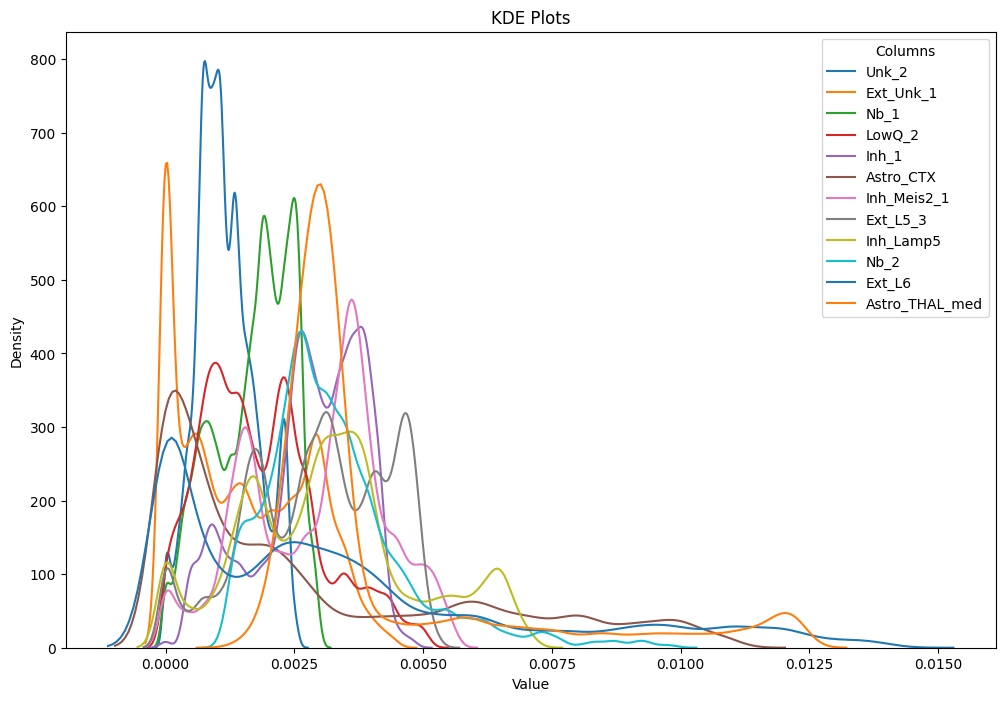

Unk_2 

Dip Statistic: 0.010149379369251, p-value: 0.11507755502373629
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
Ext_Unk_1 

Dip Statistic: 0.016793491547531916, p-value: 0.0001207074419286025
The data is likely bimodal (reject the null hypothesis of unimodality).
Nb_1 

Dip Statistic: 0.010013321898090963, p-value: 0.12910530319410884
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
LowQ_2 

Dip Statistic: 0.015957017118549712, p-value: 0.00037911143615509957
The data is likely bimodal (reject the null hypothesis of unimodality).
Inh_1 

Dip Statistic: 0.012384994501275096, p-value: 0.017684572570890733
The data is likely bimodal (reject the null hypothesis of unimodality).
Astro_CTX 

Dip Statistic: 0.017463626852025443, p-value: 4.2039449834274656e-05
The data is likely bimodal (reject the null hypothesis of unimodality).
Inh_Meis2_1 

Dip Statistic: 0.030278865417200658, p-value: 0.0
The data

In [12]:
data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Mouse_Brain/simulator_outputs/ST52/simulated_gene_expression_average.h5ad"
ctp_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Mouse_Brain/simulator_outputs/ST52/Ground_Truth_CTP.csv"

rare = get_rare(ctp_path, 0.2)

bottom_50 = rare.index.values

print (bottom_50)


dt, dt_unfil = binned_data(ctp_path, bottom_50)

print (dt)

['1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '21' '22'
 '3' '4' '5' '6' '7' '8' '9'] 22 

['21' '19' '22' '18']
['Unnamed: 0', '21', '19', '22', '18']


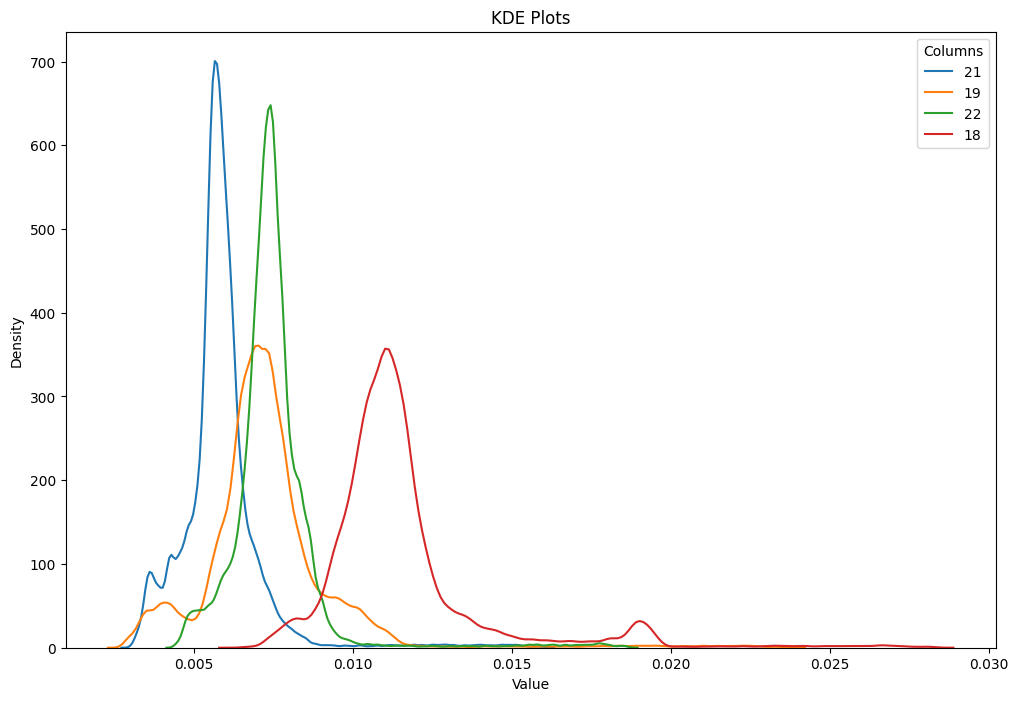

21 

Dip Statistic: 0.0017705676264670445, p-value: 0.5823783684489225
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
19 

Dip Statistic: 0.0034695942398909976, p-value: 0.0019573844728030254
The data is likely bimodal (reject the null hypothesis of unimodality).
22 

Dip Statistic: 0.0012783171242614277, p-value: 0.9727841166981758
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
18 

Dip Statistic: 0.006839631289295309, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
['19', '18']
              0  1  2  3  4  5  6  7  8
19_count  41798  0  0  0  0  0  0  0  0
18_count  41798  0  0  0  0  0  0  0  0


In [13]:
### Mouse Hippocampus

data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/SlideseqV2_benchmarking/Hippocampus/simulator_outputs/simulated_gene_expression_average.h5ad"
ctp_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/SlideseqV2_benchmarking/Hippocampus/simulator_outputs/Ground_Truth_CTP.csv"

rare = get_rare(ctp_path, 0.2)

bottom_50 = rare.index.values

print (bottom_50)


dt, dt_unfil = binned_data(ctp_path, bottom_50)

print (dt)

['1' '10' '11' '2' '3' '4' '5' '6' '7' '8' '9'] 11 

['9' '5' '11' '10']
['Unnamed: 0', '9', '5', '11', '10']


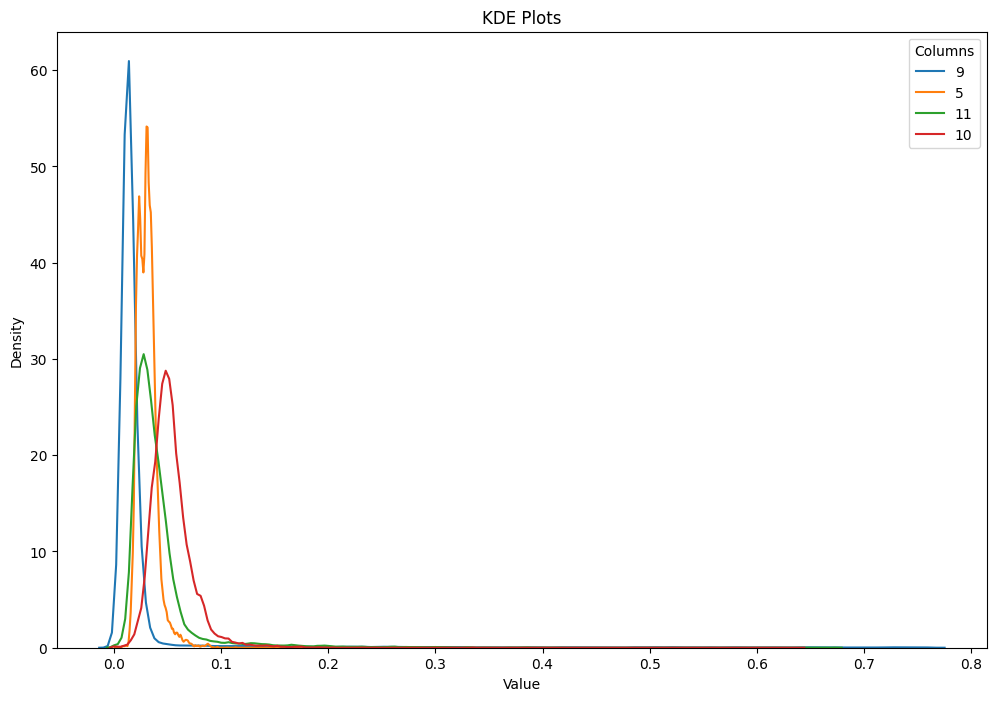

9 

Dip Statistic: 0.0013567067731105247, p-value: 0.9928587995291493
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
5 

Dip Statistic: 0.005499324350066697, p-value: 1.4391871382191113e-05
The data is likely bimodal (reject the null hypothesis of unimodality).
11 

Dip Statistic: 0.0009498884188375007, p-value: 1.0
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
10 

Dip Statistic: 0.0010967207443222811, p-value: 0.998503466575898
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
['5']
             0  1  2  3  4  5  6  7  8
5_count  27192  4  0  0  0  0  0  0  0


In [15]:
### Mouse Cerebellum

data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/SlideseqV2_benchmarking/Cerebellum/simulator_outputs/simulated_gene_expression_average.h5ad"
ctp_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/SlideseqV2_benchmarking/Cerebellum/simulator_outputs/Ground_Truth_CTP.csv"

rare = get_rare(ctp_path, 0.4)

bottom_50 = rare.index.values

print (bottom_50)


dt, dt_unfil = binned_data(ctp_path, bottom_50)

print (dt)


['Astrocytes' 'Endo' 'Excitatory' 'Inhibitory' 'Micro' 'Oligo-OPC' 'Other'] 7 

['Endo' 'Micro' 'Excitatory']
['Unnamed: 0', 'Endo', 'Micro', 'Excitatory']


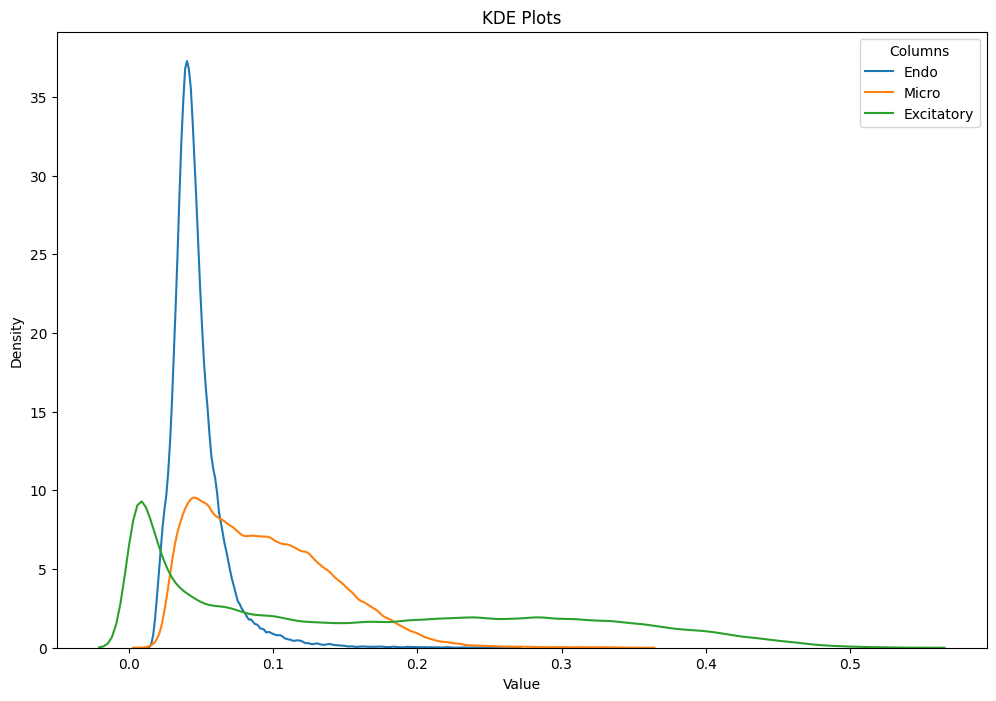

Endo 

Dip Statistic: 0.0005249706615412538, p-value: 1.0
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
Micro 

Dip Statistic: 0.0005768782636386455, p-value: 0.9988778452619075
The data is not significantly bimodal (fail to reject the null hypothesis of unimodality).
Excitatory 

Dip Statistic: 0.006109219084703142, p-value: 0.0
The data is likely bimodal (reject the null hypothesis of unimodality).
['Excitatory']
                      0      1      2      3     4    5  6  7  8
Excitatory_count  42135  16451  18383  14801  4694  128  0  0  0


/home/ajita/anaconda3/envs/cellcharter-env/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(


In [17]:
### Mouse Brain Visium HD - simulated gene expression not ready yet !!!!.

data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Mouse_brain_VisiumHD/simulator_outputs/simulated_gene_expression_average.h5ad"
ctp_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Mouse_brain_VisiumHD/simulator_outputs/Ground_Truth_CTP.csv"

rare = get_rare(ctp_path, 0.4)

bottom_50 = rare.index.values

print (bottom_50)


dt, dt_unfil = binned_data(ctp_path, bottom_50)

print (dt)
